# Multi-Branch Model - Huấn luyện mô hình đa nhánh

---

Mục tiêu là xây dựng một mô hình đa nhánh, đầu vào là `RBG` và đi vào cách nhánh với mỗi nhánh nhận một đặc điểm của ảnh và vai trò khác nhau nhằm trích xuất ra đặc trưng tốt nhât dể gộp vào lớp cuối cùng và phân loại ra `real` và `spoof`.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
from math import ceil
from pathlib import Path

import tensorflow as tf
from keras.optimizers import AdamW
from keras.optimizers.schedules import CosineDecay
from keras.losses import BinaryFocalCrossentropy
from keras.utils import set_random_seed
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report

sys.path.append(os.path.abspath('..'))
from models.MultiBranchModel import multibranch_model
from src.data import build_balanced_train_ds, build_eval_ds, clear_cache
from src.evaluate import MetricsCallback, plot_training_history, evaluate_model, calculate_metrics, find_eer_threshold

I0000 00:00:1791606523.306553 1069988 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791606523.347698 1069988 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791606524.596185 1069988 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
IMG_SIZE = 224
EPOCHS = 30
BATCH_SIZE = 32
SEED = 42
OUTPUT_DIR = '../outputs/multibranch-model'
CACHE = '../cache/multibranch-model'

set_random_seed(SEED)

import shutil
if os.path.exists(CACHE):
    shutil.rmtree(CACHE)
os.makedirs(CACHE, exist_ok=True)
clear_cache(CACHE)

## 1. Chuẩn bị dữ liệu

---

In [3]:
train_dir = '../datasets/LCC_FASD/train'
val_dir   = '../datasets/LCC_FASD/val'
test_dir  = '../datasets/LCC_FASD/test'

train_ds = build_balanced_train_ds(train_dir, IMG_SIZE, BATCH_SIZE, cache_dir=CACHE, seed=SEED)
val_ds   = build_eval_ds(val_dir,  IMG_SIZE, BATCH_SIZE, 'val',  cache_dir=CACHE)
test_ds  = build_eval_ds(test_dir, IMG_SIZE, BATCH_SIZE, 'test', cache_dir=CACHE)

x, y = next(iter(train_ds))
print(x.shape, float(tf.reduce_min(x)), float(tf.reduce_max(x)), int(tf.reduce_sum(y)))

Train: 1223 real | 7076 spoof | mỗi batch 16 real + 16 spoof


E0000 00:00:1791606526.048605 1069988 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


val: 2948 ảnh
test: 7580 ảnh


W0000 00:00:1791606527.951347 1070132 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


(32, 224, 224, 3) 0.0 1.0 16


W0000 00:00:1791606530.367292 1069988 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## 2. Khởi tạo mô hình

---

Mô hình được xây dựng trong [MultiBranchModel](../models/MultiBranchModel.py)

In [4]:
input_shape = (IMG_SIZE, IMG_SIZE, 3)

model = multibranch_model(input_shape=input_shape, num_classes=1)
model.build((None, IMG_SIZE, IMG_SIZE, 3))
model.summary()

Model: "multibranch_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ rgb_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 224, 224,  │          0 │ rgb_input[0][0]   │
│                     │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fft_channels        │ (None, 224, 113,  │          0 │ rgb_input[0][0]   │
│ (Lambda)            │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ texture_channels    │ (None, 224, 224,  │          0 │ rgb_input[0][0]   │
│ (Lambda)            │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ srm_channels        │ (None, 224, 224,  │          0 │ rgb_input[0][0]   │
│ (Lambda)            │ 9)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ color_branch        │ (None, 14, 14,    │     34,082 │ lambda[0][0]      │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fft_branch          │ (None, 14, 8,     │     32,914 │ fft_channels[0][… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ texture_branch      │ (None, 14, 14,    │     35,542 │ texture_channels… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rgb_branch          │ (None, 28, 28,    │     37,046 │ rgb_input[0][0]   │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ srm_branch          │ (None, 14, 14,    │     34,958 │ srm_channels[0][… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ color_branch[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ color_branch[0][… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ fft_branch[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ fft_branch[0][0]  │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ texture_branch[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ texture_branch[0… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ rgb_branch[0][0]

 Total params: 504,020 (1.92 MB)

 Trainable params: 500,438 (1.91 MB)

 Non-trainable params: 3,582 (13.99 KB)

In [5]:
metrics_callback = MetricsCallback(val_dataset=val_ds, threshold_path=OUTPUT_DIR + '/best_threshold.txt')

callbacks = [
    metrics_callback,

    ModelCheckpoint(
        filepath=OUTPUT_DIR + '/best_model.keras', 
        monitor='val_acer', 
        save_best_only=True, 
        mode='min', 
        verbose=1
    )
]

num_train = sum(1 for p in Path(train_dir).rglob('*.png') if p.is_file())
steps_per_epoch = ceil(num_train / BATCH_SIZE)

lr_schedule = CosineDecay(
    initial_learning_rate=0.000363,
    decay_steps=EPOCHS * steps_per_epoch
)

W0000 00:00:1791606533.749444 1069988 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [8]:
output_names = ["texture_output", "color_output", "rgb_output", "fft_output", "srm_output", "final_output"]

def to_multi_output(x, y):
    return x, {name: y for name in output_names}

train_ds_multi = train_ds.map(to_multi_output)
val_ds_multi = val_ds.map(to_multi_output)

loss_weights = {name: 1.0 for name in output_names}

model.compile(
    optimizer=AdamW(learning_rate=lr_schedule, weight_decay=2e-3),
    loss={name: BinaryFocalCrossentropy(gamma=2.0) for name in output_names},
    loss_weights=loss_weights,
    metrics={"final_output": ["accuracy"]},
)

## 3. Huấn luyện mô hình

---

In [9]:
history = model.fit(
    train_ds_multi,
    validation_data=val_ds_multi,
    epochs=EPOCHS,
    callbacks=callbacks,
    steps_per_epoch=steps_per_epoch,
    shuffle=False
)

Epoch 1/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 842ms/step - color_output_loss: 0.2699 - fft_output_loss: 0.3843 - final_output_accuracy: 0.6362 - final_output_loss: 0.2819 - loss: 2.0903 - rgb_output_loss: 0.1951 - srm_output_loss: 0.3265 - texture_output_loss: 0.6326 - APCER: 42.19% - BPCER: 42.22% - EER: 42.21% - ACER: 42.21% (t*: 0.4857) ⭐ NEW BEST

Epoch 1: val_acer improved from None to 0.42208, saving model to ../outputs/multibranch-model/best_model.keras

Epoch 1: finished saving model to ../outputs/multibranch-model/best_model.keras
260/260 ━━━━━━━━━━━━━━━━━━━━ 278s 1s/step - color_output_loss: 0.2699 - fft_output_loss: 0.3843 - final_output_accuracy: 0.6362 - final_output_loss: 0.2819 - loss: 2.0903 - rgb_output_loss: 0.1951 - srm_output_loss: 0.3265 - texture_output_loss: 0.6326 - val_color_output_loss: 0.2067 - val_fft_output_loss: 0.1723 - val_final_output_accuracy: 0.1374 - val_final_output_loss: 0.1861 - val_loss: 1.0883 - val_rgb_output_loss: 0.2276 - val_srm_output_loss: 0.

W0000 00:00:1791606882.998011 1070811 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - color_output_loss: 0.1968 - fft_output_loss: 0.2109 - final_output_accuracy: 0.7376 - final_output_loss: 0.1354 - loss: 1.1965 - rgb_output_loss: 0.1667 - srm_output_loss: 0.2560 - texture_output_loss: 0.2306 - APCER: 21.90% - BPCER: 21.98% - EER: 21.94% - ACER: 21.94% (t*: 0.4113) ⭐ NEW BEST

Epoch 2: val_acer improved from 0.42208 to 0.21939, saving model to ../outputs/multibranch-model/best_model.keras

Epoch 2: finished saving model to ../outputs/multibranch-model/best_model.keras
260/260 ━━━━━━━━━━━━━━━━━━━━ 259s 995ms/step - color_output_loss: 0.1968 - fft_output_loss: 0.2109 - final_output_accuracy: 0.7376 - final_output_loss: 0.1354 - loss: 1.1965 - rgb_output_loss: 0.1667 - srm_output_loss: 0.2560 - texture_output_loss: 0.2306 - val_color_output_loss: 0.2147 - val_fft_output_loss: 0.1444 - val_final_output_accuracy: 0.4725 - val_final_output_loss: 0.1973 - val_loss: 1.2665 - val_rgb_output_loss: 0.1768 - val_srm_output_loss: 0.4185 

## 4. Đánh giá kết quả 

---

In [ ]:
# Nạp lại trọng số của epoch tốt nhất (val_acer thấp nhất)
model.load_weights(OUTPUT_DIR + '/best_model.keras')

threshold_best = float(open(OUTPUT_DIR + '/best_threshold.txt').read())
print(f"Ngưỡng tốt nhất: {threshold_best}")

test_preds = model.predict(test_ds)
y_prob = test_preds["final_output"].flatten()
y_pred = (y_prob >= threshold_best).astype(int)

y_true = np.concatenate([y.numpy() if hasattr(y, 'numpy') else y for x, y in test_ds], axis=0).flatten()
print(classification_report(y_true, y_pred))

Ngưỡng tốt nhất: 0.256015419960022
236/236 ━━━━━━━━━━━━━━━━━━━━ 35s 146ms/step


W0000 00:00:1791594715.895771  978611 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


              precision    recall  f1-score   support

         0.0       0.22      0.82      0.34       314
         1.0       0.99      0.87      0.93      7217

    accuracy                           0.87      7531
   macro avg       0.60      0.85      0.63      7531
weighted avg       0.96      0.87      0.90      7531



Đã lưu biểu đồ lịch sử tại: ../outputs/multibranch-model/training_history.png


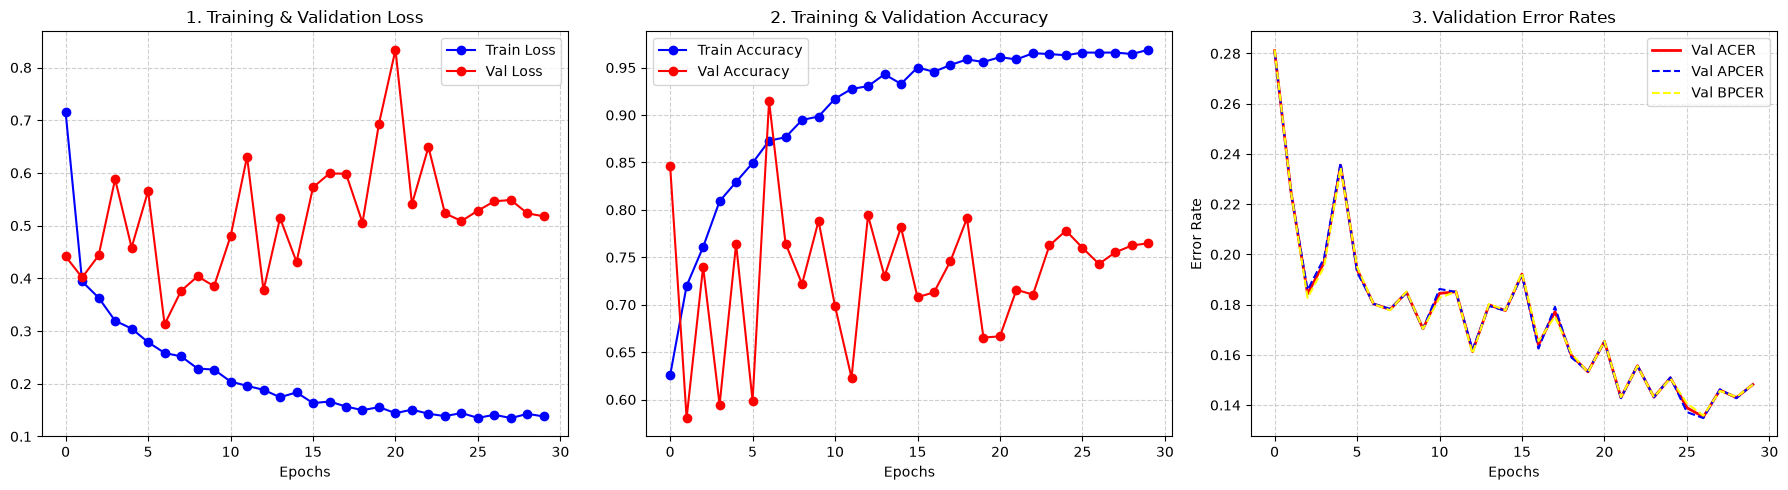

In [ ]:
plot_training_history(history.history, output=OUTPUT_DIR + '/training_history.png')

92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 158ms/step
Đã lưu biểu đồ tại: ../outputs/multibranch-model/evaluation_report.png


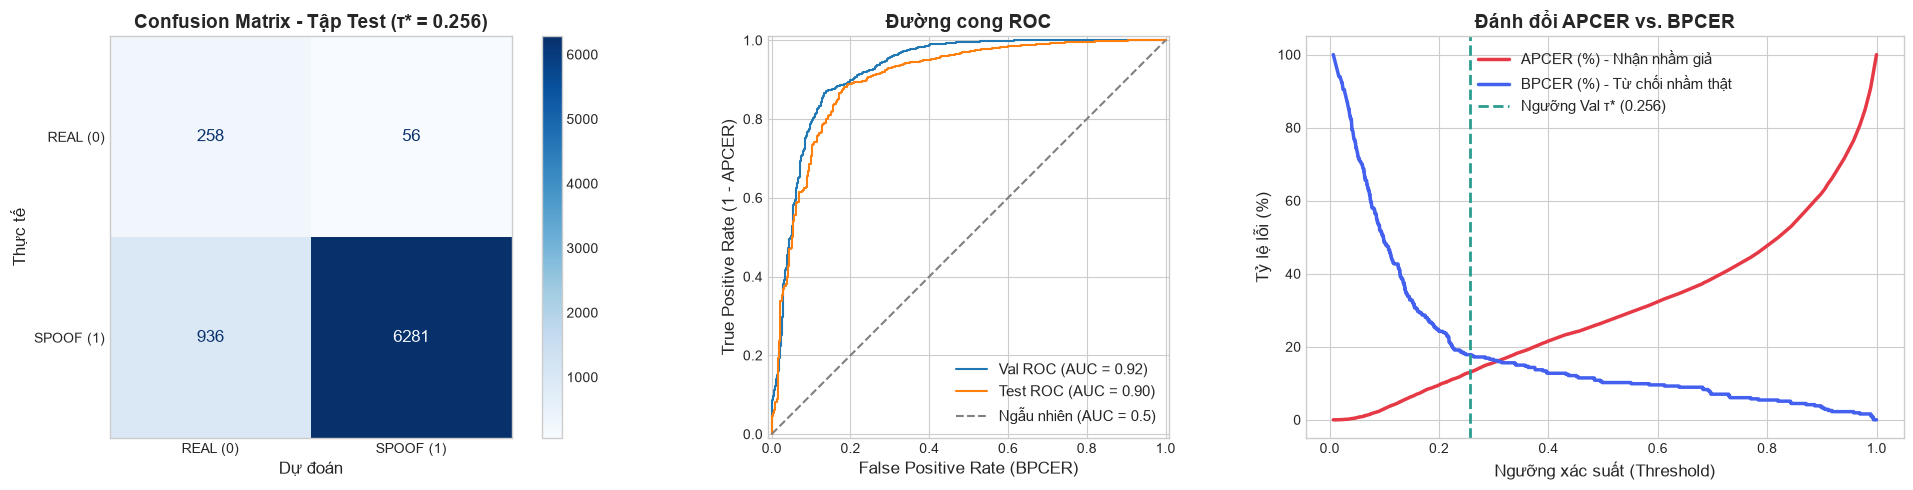

In [ ]:
val_preds = model.predict(val_ds)
y_val_prob = val_preds["final_output"].flatten()
y_val_true = np.concatenate([y.numpy() if hasattr(y, 'numpy') else y for x, y in val_ds], axis=0).flatten()

evaluate_model((y_true, y_prob), (y_val_true, y_val_prob), threshold_best, output=OUTPUT_DIR + '/evaluation_report.png')

In [ ]:
branch_names = ["texture_output", "color_output", "rgb_output", "fft_output", "srm_output", "final_output"]

results = []
for name in branch_names:
    threshold = find_eer_threshold(y_val_true, val_preds[name].flatten())
    report = calculate_metrics(y_true, test_preds[name].flatten(), threshold)
    results.append({"Branch": name, "Threshold": threshold, **report})

metrics = pd.DataFrame(results)
metrics

,Branch,EER (%),APCER (%),BPCER (%),ACER (%),AUC (%),ACC (%)
0,texture_output,30.573248,10.128862,58.280255,34.204559,73.395971,87.863498
1,color_output,19.745223,5.750312,46.178344,25.964328,87.821174,92.564069
2,rgb_output,16.560510,4.891229,50.000000,27.445615,89.550327,93.227991
3,fft_output,33.439490,2.410974,90.445860,46.428417,70.072387,93.918470
4,srm_output,34.076433,2.604961,92.993631,47.799296,72.094616,93.626344
5,final_output,16.242038,12.969378,17.834395,15.401886,90.200156,86.827779
